```
┌──────────────────────────────────────────────────────────────┐
│ Mini-Projeto avaliativo Módulo 1                             │
│ Aluno: Luiz Felipe F. V. Vieira                              │
└──────────────────────────────────────────────────────────────┘

┌──────────────────────────────────────────────────────────────┐
│                                                              │
│ Na documentação do Mini-Projeto foi solicitado               │
│ a entrega em 1 arquivo .ipynb, por isso toda a lógica        │
│ de ETL e AED se encontram neste arquivo único.               │
│                                                              │
├──────────────────────────────────────────────────────────────┤
│                                                              │
│ Fluxo do Pipeline de dados:                                  │
│                                                              │
│ 1- EXTRACT - Verificação e conhecimento da base              │
│ 2- TRANSFORM - Ajuste de colunas (Excluir e renomear)        │
│ 3- TRANSFORM - Limpeza dos dados (DUPLICADOS)                │
│ 4- TRANSFORM - Correção dos dados e tratamento               │
│   -> Correção de tipos (str > datetime)                      │
│   -> Conversão e otimização dos tipos de dados               │
│   -> Inconsistência de dados                                 │
│   -> Engenharia de Features                                  │
│ 5. LOAD - Gerar nova base limpa                              │
│   -> Salvar em um arquivo CSV                                │
│   -> Garantir que a AED seja feita na base limpa             │
│ 6- AED - Gerar estatísticas e análises                       │
│   -> Estatísticas para coluna número de filhos:              │
│      (média; mediana; desvio padrão;                         │
│        moda; máximo; mínimo; contagem)                       │
│   -> Regra de Negócio:                                       │
│      Validar a regra do identificador de número de compra    │
│          -Nota pertence a um único cliente                   │
│          -Nota pertence a um único dia                       │
│   -> Frequência: Quantas notas um mesmo cliente emitiu?      │
│      (Criar 3 grandes grupos)                                │
│   -> Volume de Vendas por Classe Econômica                   │
│   -> Sazonalidades:                                          │
│      - Sazonalidade por Dia da Semana                        │
│      - Sazonalidade Mensal                                   │
│      - Distribuição de Vendas por Período do Mês             │
│   -> Volume de Vendas por Categoria de produtos              │
│                                                              │
├──────────────────────────────────────────────────────────────┤
│                                                              │
│ Para fins didáticos, foram mantidos todos os testes e        │
│ avaliações, mesmo que não resultasse em transformação na     │
│ base de dados.                                               │
│                                                              │
└──────────────────────────────────────────────────────────────┘
```
---

In [453]:

# IMPORTS & CONFIGURAÇÂO

import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

kaggle_path = "namespaiva/base-varejo"
kaggle_csv = "Base Varejo.csv"
nome_df_limpo = "Base_Varejo_Limpo"

path = kagglehub.dataset_download(kaggle_path)
csv_path = Path(path) / kaggle_csv

print('Bibliotecas importadas e variáveis de configuração criadas.')

Bibliotecas importadas e variáveis de configuração criadas.


```
┌──────────────────────────────────────────────────────────────┐
│ 1- EXTRACT - Verificação e conhecimento da base              │
│   -> df.head(5) / df.tail(5)                                 │
│   -> df.info()                                               │
│   -> df.isnull().sum()                                       │
└──────────────────────────────────────────────────────────────┘
```

In [454]:
# Extrair a base do csv para o DataFrame

df = pd.read_csv(csv_path, sep=';', encoding='cp1252')
print(f'Dados extraídos com sucesso da base: {csv_path}')

Dados extraídos com sucesso da base: /home/vampre/.cache/kagglehub/datasets/namespaiva/base-varejo/versions/1/Base Varejo.csv


In [455]:
print('Exibindo as primeiras 5 linhas da Base Varejo.')
df.head(5)

Exibindo as primeiras 5 linhas da Base Varejo.


,DATA,CO_ID,CL_ID,CL_GENERO,CL_EC,CL_FHL,CL_SEG,PR_ID,PR_CAT,PR_NOME,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13
0,01/02/2019,1000,534,M,4,1,C,67,BEBIDAS,REFRIGERANTE GUARANA,NaN,NaN,NaN,NaN
1,01/02/2019,1000,534,M,4,1,C,70,BEBIDAS,REFRIGERANTE OUTROS,NaN,NaN,NaN,NaN
2,01/02/2019,1000,534,M,4,1,C,178,HIGIENE,LENCO UMEDECIDO,NaN,NaN,NaN,NaN
3,01/02/2019,1000,534,M,4,1,C,4,ALIMENTOS,ABACAXI,NaN,NaN,NaN,NaN
4,01/02/2019,1000,534,M,4,1,C,175,LIMPEZA,LIMPADOR MULTIUSO,NaN,NaN,NaN,NaN


In [456]:
print('Exibindo as Últimas 5 linhas da Base Varejo')
df.tail(5)

Exibindo as Últimas 5 linhas da Base Varejo


,DATA,CO_ID,CL_ID,CL_GENERO,CL_EC,CL_FHL,CL_SEG,PR_ID,PR_CAT,PR_NOME,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13
829995,19/08/2022,919822,155,F,2,0,B,183,ALIMENTOS,KETCHUP,NaN,NaN,NaN,NaN
829996,19/08/2022,919822,155,F,2,0,B,56,ALIMENTOS,QUEIJO MUSSARELA,NaN,NaN,NaN,NaN
829997,19/08/2022,919822,155,F,2,0,B,227,ALIMENTOS,ARROZ,NaN,NaN,NaN,NaN
829998,19/08/2022,919822,155,F,2,0,B,214,ALIMENTOS,CEBOLA,NaN,NaN,NaN,NaN
829999,19/08/2022,919822,155,F,2,0,B,59,ALIMENTOS,SALGADINHO,NaN,NaN,NaN,NaN


In [457]:
print('Exibindo número de registros, colunas, valores não nulos e tipo de dados.')
df.info()

Exibindo número de registros, colunas, valores não nulos e tipo de dados.
<class 'pandas.DataFrame'>
RangeIndex: 830000 entries, 0 to 829999
Data columns (total 14 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   DATA         830000 non-null  str    
 1   CO_ID        830000 non-null  int64  
 2   CL_ID        830000 non-null  int64  
 3   CL_GENERO    830000 non-null  str    
 4   CL_EC        830000 non-null  int64  
 5   CL_FHL       830000 non-null  int64  
 6   CL_SEG       830000 non-null  str    
 7   PR_ID        830000 non-null  int64  
 8   PR_CAT       830000 non-null  str    
 9   PR_NOME      830000 non-null  str    
 10  Unnamed: 10  0 non-null       float64
 11  Unnamed: 11  0 non-null       float64
 12  Unnamed: 12  0 non-null       float64
 13  Unnamed: 13  0 non-null       float64
dtypes: float64(4), int64(5), str(5)
memory usage: 88.7 MB


---
```
┌──────────────────────────────────────────────────────────────┐
│ 2- TRANSFORM - Ajuste de colunas (Excluir e renomear)        │
│   -> criação df_limpo                                        │
│   -> df.drop()                                               │
│   -> df.columns -> Renomear as Colunas                       │
├────────┬────────────┬────────────────────────────────────────┤
│ Coluna │    Nome    │              Renomeação                │
├────────┼────────────┼────────────────────────────────────────┤
│   1    │  DATA      │ Data                                   │
│   2    │  CO_ID     │ Nota_Fiscal                            │
│   3    │  CL_ID     │ Num_Cliente                            │
│   4    │  CL_GENERO │ Sexo                                   │
│   5    │  CL_EC     │ Estado_Civil                           │
│   6    │  CL_FHL    │ Num_Filhos                             │
│   7    │  CL_SEG    │ Classe_Economica                       │
│   8    │  PR_ID     │ Cod_Produto                            │
│   9    │  PR_CAT    │ Cat_Produto                            │
│  10    │  PR_NOME   │ Nome_Produto                           │
├────────┴────────────┴────────────────────────────────────────┤
│ Estado_Civil:                                                │
│       1: Casado ou união estával;                            │
│       2: Divorciado;                                         │
│       3: Separado;                                           │
│       4. Solteiro;                                           │
│       5: Viúvo.                                              │
└──────────────────────────────────────────────────────────────┘
```

In [458]:
# Remover colunas excedentes criando novo DataFrame df_limpo

remover_colunas = ['Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13']
df_limpo = df.drop(columns=remover_colunas, errors='ignore')

print('Colunas removidas. Colunas restantes na base:')
print(df_limpo.columns.to_list())

Colunas removidas. Colunas restantes na base:
['DATA', 'CO_ID', 'CL_ID', 'CL_GENERO', 'CL_EC', 'CL_FHL', 'CL_SEG', 'PR_ID', 'PR_CAT', 'PR_NOME']


In [459]:
# Renomear todas as colunas

nome_colunas = ['Data', 'Nota_Fiscal', 'Num_Cliente', 'Sexo', 'Estado_Civil', 'Num_Filhos', 'Classe_Economica', 'Cod_Produto', 'Cat_Produto', 'Nome_Produto']

# Se for diferente, retorna aviso e não executa
if len(nome_colunas) != len(df_limpo.columns):
    print(
        f'O número de novos nomes ({len(nome_colunas)}) deve ser igual '
        f'\n ao número de colunas do DataFrame ({len(df_limpo.columns)}).'
    )
else:
    df_limpo.columns = nome_colunas
    print('Colunas renomeadas. Colunas atuais na base:')
    print(df_limpo.columns.to_list())

Colunas renomeadas. Colunas atuais na base:
['Data', 'Nota_Fiscal', 'Num_Cliente', 'Sexo', 'Estado_Civil', 'Num_Filhos', 'Classe_Economica', 'Cod_Produto', 'Cat_Produto', 'Nome_Produto']


---
```
┌──────────────────────────────────────────────────────────────┐
│ 3- TRANSFORM -  Limpeza dos dados [DUPLICADOS]               │
│                                                              │
│ Mais de um produto na mesma nota? Faz sentido nessa base?    │
│                                                              │
│ Durante a análise preliminar dos duplicados, foram           │
│ identificados 96.553 registros repetidos (11,6% da base).    │
│ Considerando a ausência de uma coluna de quantidade e o      │
│ contexto de vendas no varejo, foi realizada uma investigação │
│ minusciosa para verificar se essas repetições correspondiam  │
│ a inconsistências nos dados ou à representação de múltiplas  │
│ unidades vendidas do mesmo produto em uma mesma nota fiscal. │
│                                                              │
│ Os resultados indicaram que as repetições representam        │
│ quantidades comercializadas e por isso não foram excluídas   │
│ da base.                                                     │
│                                                              │
│ ANALISANDO O IMPACTO DA REMOÇÃO DE LINHAS DUPLICADAS         │
└──────────────────────────────────────────────────────────────┘
```

In [460]:
#############################################################
# Exibindo total linhas, únicas e duplicadas
# Objetivo: mostrar quantos registros seriam perdidos 
# ao aplicar drop_duplicates().
#############################################################

total_linhas = len(df_limpo)
linhas_unicas = len(df_limpo.drop_duplicates())
duplicadas = total_linhas - linhas_unicas

print('Mostrando o impacto da remoção dos duplicados:')    
print(f'Total de linhas: {total_linhas:,}')
print(f'Linhas únicas: {linhas_unicas:,}')
print(f'Linhas duplicadas: {duplicadas:,}')
print(f'Percentual removido: {(duplicadas/total_linhas)*100:.2f}%')

Mostrando o impacto da remoção dos duplicados:
Total de linhas: 830,000
Linhas únicas: 733,447
Linhas duplicadas: 96,553
Percentual removido: 11.63%


In [461]:
#############################################################
# Frequência dos produtos nas notas
# Objetivo: verificar quantas vezes um mesmo produto 
# aparece dentro da mesma nota fiscal.
#############################################################

# Contar quantas vezes cada combinação Nota Fiscal + Produto ocorre
freq_produtos = (
    df_limpo.groupby(['Nota_Fiscal', 'Cod_Produto'])
      .size()
      .reset_index(name='qtd')
)

# Exibir os caso mais frequentes para análise
print('Mostrando a frequência que cada produto aparece nas notas:')
print(freq_produtos.sort_values('qtd', ascending=False).head(10))


Mostrando a frequência que cada produto aparece nas notas:
        Nota_Fiscal  Cod_Produto  qtd
459524       572388          200    6
335674       418143          204    6
40561         51705           36    6
296351       371146          217    5
638894       803867          134    5
221497       277935          205    5
635697       800035          134    5
594695       747629           35    5
654697       824238          129    5
246980       309914          140    5


In [462]:
#############################################################
# Estatísticas descritivas das quantidades encontradas
# Objetivo: verificar se as repetições seguem um padrão 
# compatível com quantidade vendida.
#############################################################

print('Mostrando a estatística nas quantidades encontradas:')
freq_produtos['qtd'].describe()

    

Mostrando a estatística nas quantidades encontradas:


count    733447.000000
mean          1.131643
std           0.374184
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max           6.000000
Name: qtd, dtype: float64

**CONCLUSÃO:**

-> 75% dos produtos aparecem apenas uma vez por nota 

-> Poucas ocorrências com múltiplas unidades 

-> Média de 1.13 produtos por nota 

-> Nenhuma frequência anormal foi observada 


In [463]:
#############################################################    
# Análise detalhada de uma nota fiscal. 
# Objetivo: verificar se diferentes produtos aparecem 
# em qtde diferentes dentro da mesma compra.
#############################################################

# Nf exemplo:
nota = 477026

# Quantidade de ocorrências de cada produto nessa nota
itens_nota = (
    df_limpo[df_limpo['Nota_Fiscal'] == nota]
      .groupby('Cod_Produto')
      .size()
      .sort_values(ascending=False)
)

print(f'Mostrando quantidade de produtos na nota fiscal exemplo n.{nota}')
print(itens_nota.head(10))

Mostrando quantidade de produtos na nota fiscal exemplo n.477026
Cod_Produto
25     4
90     3
99     3
6      2
68     2
80     2
45     2
19     2
103    2
110    2
dtype: int64


**CONCLUSÃO:**

-> Produtos diferentes possuem quantidades diferentes 

-> O padrão é compatível com uma compra contendo múltiplas unidades 


In [464]:
#############################################################    
# Analisar o impacto da remoção de duplicatas em cada nota
# Objetivo: verificar como o drop_duplicates() 
# altera a composição das notas.
#############################################################    

# Quantidade de itens por nota na base limpa
itens_original = df_limpo.groupby('Nota_Fiscal').size()

# Quantidade de itens por nota após remover duplicatas
itens_sem_dup = (df_limpo.drop_duplicates().groupby('Nota_Fiscal').size())

# Criar DataFrame misto para comparacao
comparacao = pd.DataFrame({
    'original': itens_original,
    'sem_duplicacao': itens_sem_dup
})

# Criar coluna "diferenca" para análise
comparacao['diferenca'] = (comparacao['original']- comparacao['sem_duplicacao'])

print('Mostrando quantidade de itens removidos em cada nota com drop_duplicates():')
print(comparacao.sort_values('diferenca', ascending=False).head(10))


Mostrando quantidade de itens removidos em cada nota com drop_duplicates():
             original  sem_duplicacao  diferenca
Nota_Fiscal                                     
477026             88              64         24
849764             89              65         24
699110             89              65         24
835405             88              65         23
11195              88              65         23
441155             87              64         23
620815             89              67         22
597035             89              67         22
205318             82              60         22
489575             87              65         22


**CONCLUSÃO:**

-> Algumas notas perderiam mais de 20 itens 

-> A remoção das linhas repetidas alteraria significativamente o conteúdo das vendas

---



**CONCLUSÃO FINAL SOBRE drop_duplicates:**

Após análise minusciosa da Base em relação as linhas repetidas, concluiu-se:
                                                              
1. A remoção de duplicatas eliminaria 11,6% da base
2. As repetições por produto possuem frequência máxima de apenas 6 ocorrências
3. A distribuição das frequências é compatível com quantidades vendidas
4. Produtos diferentes apresentam quantidades diferentes dentro da mesma nota fiscal
5. A remoção dos registros alteraria substancialmente a composição das notas
                                                              
Portanto, os registros repetidos foram interpretados como representação implícita da quantidade vendida de cada produto, e não como erros de duplicação dos dados. Dessa forma, os registros foram mantidos na base analítica.

---
```
┌──────────────────────────────────────────────────────────────┐
│ 4- TRANSFORM - Correção dos dados e tratamento               │
│   -> Correção de tipos (str > datetime)                      │
│   -> Conversão e otimização dos tipos de dados               │
│   -> Inconsistência de dados                                 │
│   -> Engenharia de Features                                  │
└──────────────────────────────────────────────────────────────┘
```

```
┌──────────────────────────────────────────────────────────────┐
│   -> Correção de tipos (str > datetime)                      │
└──────────────────────────────────────────────────────────────┘
```

In [465]:
# Converter coluna Data para datetime, colocando NaT onde falhar
df_limpo['Data'] = pd.to_datetime(df_limpo['Data'], format='%d/%m/%Y', errors='coerce')   

print('Coluna Data transformada no tipo datetime com sucesso!')
print(f'Novo tipo de dado da coluna Data: {df_limpo['Data'].dtype}')

Coluna Data transformada no tipo datetime com sucesso!
Novo tipo de dado da coluna Data: datetime64[us]


In [466]:
#############################################################    
# Inconsistência de dados -> Data: Válida ou NaT?
# Objetivo: Validar coluna de Data
#############################################################    

datas_invalidas = df_limpo['Data'].isna().sum()
print(f'Linhas com Datas inválidas: {datas_invalidas}')

Linhas com Datas inválidas: 0


```
┌──────────────────────────────────────────────────────────────┐
│   -> Conversão e otimização dos tipos de dados               │
└──────────────────────────────────────────────────────────────┘
```

Realizar a adequação dos tipos de dados das colunas visando reduzir o consumo de memória e melhorar a eficiência das operações analíticas. 

Colunas categóricas -> Converter para o tipo category </br>
Colunas numéricas -> Ajustar para tipo mais compacto (int8)


In [467]:
#############################################################    
# Conversão de dados -> Cálculo de memória utilizada 
# Objetivo: Verificar memória utilizada na base ANTES da otimização
#############################################################    

# memory_usage(deep=True): Calcula a memória exata
# .sum(): Soma o consumo de todas as colunas e do índice.
# / 1024**2: Converte o total de bytes (unidade nativa do pandas)
#  para megabytes (base-2, onde 1 MB = 1024 KB).
memoria_antes = df.memory_usage(deep=True).sum() / 1024**2

print(f'Memória utilizada antes da otimização: {memoria_antes:.2f}')

Memória utilizada antes da otimização: 275.03


In [468]:
#############################################################    
# Conversão de dados -> Classificação dos dados
# Objetivo: Verificar quais colunas podem ser consideradas "category" e "int8"
#############################################################    

# Criar um DataFrame a partir de um dicionário
# Investigando o percentual de valores em relação a quantidade de linhas
resumo = pd.DataFrame({
    'Qtd_Unicos': df_limpo.nunique(),
    'Percentual (%)': (df_limpo.nunique() / len(df_limpo) * 100).round(2)
})

print('Mostrando número de valores únicos / percentual em cada coluna:')
print(resumo)   


Mostrando número de valores únicos / percentual em cada coluna:
                  Qtd_Unicos  Percentual (%)
Data                     333            0.04
Nota_Fiscal            18471            2.23
Num_Cliente             1000            0.12
Sexo                       2            0.00
Estado_Civil               5            0.00
Num_Filhos                 5            0.00
Classe_Economica           3            0.00
Cod_Produto              229            0.03
Cat_Produto                7            0.00
Nome_Produto             118            0.01


**CONCLUSÃO:**

-> As colunas Nota_Fiscal, Num_Cliente, Sexo, Estado_Civil, Classe_Economica, Cod_Produto, Cat_Produto e Nome_Produto possuem um conjunto bastante limitado de valores repetidos. Como nesta AED não será feito ordenação, operações numéricas nem trabalhar com intervalos nestas colunas, elas serão transformadas no tipo "category".

-> A coluna Num_Filhos será convertida para "int8" que ocupa apenas  1 byte. Apesar de ter apenas 5 valores distintos, é uma variável quantitativa e iremos fazer análises estatísticas.


In [469]:
#############################################################    
# Conversão de dados -> Executar
# Objetivo: Converter os dados após análise prévia
#############################################################    

# Conversão da coluna Num_Filhos
df_limpo['Num_Filhos'] = df_limpo['Num_Filhos'].astype('int8')

# Conversão das colunas de Categoria
categorias = [
    'Nota_Fiscal',
    'Num_Cliente',
    'Sexo',
    'Estado_Civil',
    'Classe_Economica',
    'Cod_Produto',
    'Cat_Produto',
    'Nome_Produto'    
]

for col in categorias:
    df_limpo[col] = df_limpo[col].astype('category')

print('Mostrando o nome da coluna e seu respectivo tipo de dado:')
print(df_limpo.dtypes)   

Mostrando o nome da coluna e seu respectivo tipo de dado:
Data                datetime64[us]
Nota_Fiscal               category
Num_Cliente               category
Sexo                      category
Estado_Civil              category
Num_Filhos                    int8
Classe_Economica          category
Cod_Produto               category
Cat_Produto               category
Nome_Produto              category
dtype: object


In [470]:
#############################################################    
# Conversão de dados -> Cálculo de memória utilizada 
# Objetivo: Verificar memória utilizada na base DEPOIS da otimização
#############################################################    

# memory_usage(deep=True): Calcula a memória exata
# .sum(): Soma o consumo de todas as colunas e do índice.
# / 1024**2: Converte o total de bytes (unidade nativa do pandas)
#  para megabytes (base-2, onde 1 MB = 1024 KB).
memoria_depois = df_limpo.memory_usage(deep=True).sum() / 1024**2

print(f'Memória utilizada antes da otimização: {memoria_antes:.2f}')
print(f'Memória utilizada depois da otimização: {memoria_depois:.2f}')
print(f'Economia de memória: {(1 - (memoria_depois / memoria_antes))* 100:.2f}%')


Memória utilizada antes da otimização: 275.03
Memória utilizada depois da otimização: 15.99
Economia de memória: 94.19%


```
┌──────────────────────────────────────────────────────────────┐
│   -> Inconsistência de dados                                 │
└──────────────────────────────────────────────────────────────┘
```

In [471]:
#############################################################     
# Inconsistência de dados -> Sexo: Somente M e F?
# Objetivo: Validar coluna de Sexo
#############################################################    

print('Valores encontrados na coluna Sexo:')
print(df_limpo['Sexo'].value_counts(dropna=False))

Valores encontrados na coluna Sexo:
Sexo
F    432576
M    397424
Name: count, dtype: int64


In [472]:
#############################################################    
# Inconsistência de dados -> ESTADO CIVIL: Somente de 1 a 5?
# Objetivo: Validar coluna Estado_Civil
#############################################################    

print('Valores encontrados na coluna Estado_Civil:')
print(df_limpo['Estado_Civil'].value_counts().sort_index())

Valores encontrados na coluna Estado_Civil:
Estado_Civil
1    194873
2    194990
3    213742
4    202618
5     23777
Name: count, dtype: int64


In [473]:
#############################################################    
# Inconsistência de dados -> CLASSE ECONOMICA: Somente A, B ou C?
# Objetivo: Validar coluna Classe_Economica
#############################################################    

print('Valores encontrados na coluna Classe_Economica:')
print(df_limpo['Classe_Economica'].value_counts(dropna=False).sort_index())

Valores encontrados na coluna Classe_Economica:
Classe_Economica
A     67736
B    530163
C    232101
Name: count, dtype: int64


In [474]:
#############################################################    
# Inconsistência de dados -> CATEGORIAS: Quais? Repetidas?
# Objetivo: Verificar categoria repetida ou inexistente
#############################################################    

print('Valores encontrados na coluna Categorias:')
print(df_limpo['Cat_Produto'].value_counts())

Valores encontrados na coluna Categorias:
Cat_Produto
ALIMENTOS     434767
HIGIENE       155574
LIMPEZA       145754
BEBIDAS        43299
PET            32399
ACESSORIOS     14557
#N/D            3650
Name: count, dtype: int64


**CONCLUSÃO:**

-> Categoria "#N/D" com 3650 produtos (**Necessário investigação**)

In [475]:
#############################################################    
# Inconsistência de dados -> CATEGORIAS: Investigando '#N/D'
# Objetivo: Verificar códigos de produtos associado a categoria '#N/D'
#############################################################    

codigos_produtos = df_limpo[df_limpo['Cat_Produto'] == '#N/D']['Cod_Produto'].unique()
print('Códigos de produtos encontrados para categoria "#N/D:')
print(codigos_produtos)

Códigos de produtos encontrados para categoria "#N/D:
[107]
Categories (229, int64): [1, 2, 3, 4, ..., 226, 227, 228, 229]


**CONCLUSÃO:**

-> Somente o produto com código 107 foi encontrado na categoria #N/D

In [476]:
#############################################################    
# Inconsistência de dados -> CATEGORIAS: Investigando categoria '#N/D' / Produto 107
# Objetivo: Verificar mais informações sobre o produto cód 107
#############################################################    

# Verificar se o produto 107 aparece somente na categoria #N/D
cod_107 = df_limpo[df_limpo['Cod_Produto'] == 107]
print('Informações sobre o Cod_Produto=107:')
print(cod_107[['Cod_Produto', 'Nome_Produto', 'Cat_Produto']].drop_duplicates())

# Verificar se existe outro produto com nome #N/D
nome_nd = df_limpo[df_limpo['Nome_Produto'] == '#N/D'][
    ['Cod_Produto', 'Nome_Produto', 'Cat_Produto']
].drop_duplicates()
print('\nInformações sobre o Nome_Produto=#N/D')
print(nome_nd)


Informações sobre o Cod_Produto=107:
   Cod_Produto Nome_Produto Cat_Produto
82         107         #N/D        #N/D

Informações sobre o Nome_Produto=#N/D
   Cod_Produto Nome_Produto Cat_Produto
82         107         #N/D        #N/D


**CONCLUSÃO:**

-> Na categoria #N/D existe somente o produto 107 

-> O produto cod 107 não está em outras categorias 

-> O Nome #N/D está associado somente ao produto cod 107


In [477]:
#############################################################    
# Inconsistência de dados -> CATEGORIAS: Investigando categoria '#N/D' / Produto 107
# Objetivo: Medir o impacto na inconsistência deste dado
############################################################# 

print("Linhas:", len(cod_107))
print("Notas distintas:", cod_107['Nota_Fiscal'].nunique())
print("Clientes distintos:", cod_107['Num_Cliente'].nunique())

Linhas: 3650
Notas distintas: 3228
Clientes distintos: 956


**CONCLUSÃO:**

-> Não existe informação alternativa para recuperar o produto 107 ou a categoria #N/d 

-> Os registros serão preservados e classificados como "Não Identificado" 


In [478]:
#############################################################    
# Inconsistência de dados -> CATEGORIAS: '#N/D' / PRODUTO: 107
# Objetivo: Substituir categoria #N/D e produto #N/D com "Não Identificado"
############################################################# 

# 1. Adiciona a nova categoria (Agora não é mais str e sim category)
df_limpo['Nome_Produto'] = df_limpo['Nome_Produto'].cat.add_categories('Não Identificado')
df_limpo['Cat_Produto'] = df_limpo['Cat_Produto'].cat.add_categories('Não Identificado')

# 2. Realiza a substituição dos valores
df_limpo['Nome_Produto'] = df_limpo['Nome_Produto'].replace('#N/D', 'Não Identificado')
df_limpo['Cat_Produto'] = df_limpo['Cat_Produto'].replace('#N/D', 'Não Identificado')

# 3. Remove a categoria antiga que agora está vazia
df_limpo['Nome_Produto'] = df_limpo['Nome_Produto'].cat.remove_categories('#N/D')   
df_limpo['Cat_Produto'] = df_limpo['Cat_Produto'].cat.remove_categories('#N/D')   

print('Renomeado categoria #N/D por "Não Identificado"')
print('Renomeado produto #N/D por "Não Identificado"')

Renomeado categoria #N/D por "Não Identificado"
Renomeado produto #N/D por "Não Identificado"


In [479]:
#############################################################    
# Inconsistência de dados -> Produto em multiplas categorias
# Objetivo: Verificar se um mesmo produto aparece em mais de uma categoria
#############################################################   

# Agrupar por Nome_produto e verificar categorias únicas
produtos_multiplas_categorias = (
    df_limpo.groupby('Nome_Produto')['Cat_Produto']
      .nunique()
      .reset_index()
)

# Encontradar os produtos que estão em mais de uma categoria
produtos_multiplas_categorias = (
    produtos_multiplas_categorias[
        produtos_multiplas_categorias['Cat_Produto'] > 1
    ]
)

print('Produtos em mais de uma categoria:')
print(produtos_multiplas_categorias)


Produtos em mais de uma categoria:
Empty DataFrame
Columns: [Nome_Produto, Cat_Produto]
Index: []


**CONCLUSÃO:**

-> Empty DataFrame= Não existem produtos em mais de uma categoria 

-> Validação OK, nenhuma inconsistência


In [480]:
#############################################################    
# Inconsistência de dados -> Código de Produto em multiplos produtos
# Objetivo: Verificar se um mesmo Cod_Produto aparece em mais de um Nome_Produto
#############################################################   

# Agrupar por Cod_Produto e verificar Nome_Produto únicos
cod_multiplos_produtos = (
    df_limpo.groupby('Cod_Produto')['Nome_Produto']
      .nunique()
      .reset_index()
)

# Encontradar os Cod_Produtos que estão associados a mais de um Nome
cod_multiplos_produtos = (
    cod_multiplos_produtos[
        cod_multiplos_produtos['Nome_Produto'] > 1
    ]
)

print('Código de Produtos em mais de um Nome de Produto:')
print(cod_multiplos_produtos)

Código de Produtos em mais de um Nome de Produto:
Empty DataFrame
Columns: [Cod_Produto, Nome_Produto]
Index: []


**CONCLUSÃO:**

-> Empty DataFrame= Não existem códigos de produto associado a mais de um produto 

-> Validação OK, nenhuma inconsistência


In [481]:
#############################################################    
# Inconsistência de dados -> Produtos associados a mais de um Código de Produto
# Objetivo: Verificar se um mesmo Produto tem mais de um código
#############################################################   

# Agrupar por Nome_Produto e verificar Cod_Produto únicos
produto_multiplos_cod = (
    df_limpo.groupby('Nome_Produto')['Cod_Produto']
      .nunique()
      .reset_index()
      .sort_values('Cod_Produto', ascending=False)
)

# Encontradar os Nome_Produto que estão associados a mais de um Código
produto_multiplos_cod = (
    produto_multiplos_cod[
        produto_multiplos_cod['Cod_Produto'] > 1
    ]
)

print('Nome de Produto com mais de um Código:')
print(produto_multiplos_cod)

Nome de Produto com mais de um Código:
        Nome_Produto  Cod_Produto
85   PRESUNTO COZIDO            4
13            AZEITE            2
10             ARROZ            2
11    ARROZ INTEGRAL            2
8          ALMONDEGA            2
..               ...          ...
112         TINTURAS            2
113        TIRA LIMO            2
116              UVA            2
115           TOMATE            2
117         VASSOURA            2

[109 rows x 2 columns]


**CONCLUSÃO:**

-> 108 Produtos encontrados com 2 códigos e 1 produto com 4 códigos 

-> **Investigar** para entender se é a estrutura da base ou inconsistência


In [482]:
#############################################################    
# Inconsistência de dados -> Produtos associados a mais de um Código de Produto
# Objetivo: Verificar a proporção de produtos únicos vs produtos com mais de um código
#############################################################   

produtos_unicos = df_limpo['Nome_Produto'].nunique()

print(f'{len(produto_multiplos_cod) / produtos_unicos * 100:.1f}%')


92.4%


**CONCLUSÃO:**

-> 92.4% dos produtos tem 2 códigos (quase toda a base)

-> Se fosse um erro cadastral ou problema de qualidade dos dados, esperaríamos valores menores como 5% / 10% / 15%. Se isso está ocorrendo em praticamente toda a base, não parece uma anomalia e sim uma característica do modelo de dados. 

-> A verificação anterior mostrou que o contrário não é verdadeiro, não existe Cod_Produto associado a mais de um produto, isso é mais importante para consistência cadastral. 

-> Os resultados sugerem que as ocorrências podem estar relacionadas a mudanças de codificação ou à existência de diferentes SKUs compartilhando uma mesma descrição comercial, e não necessariamente a erros cadastrais.

-> Isso sugere que a base de dados está estruturada da seguinte forma:
```
Nome_Produto (Arroz)
    ├── Cod_Produto 101 (Ex: Arroz Branco)
    └── Cod_Produto 102 (Ex: Arroz Integral)
```

-> Conclusão Final: Não é uma inconsistência.

In [483]:
#############################################################    
# Inconsistência de dados -> SKU como Primaty Key
# Objetivo: Verificar final da Dimensão dos produtos vs Cod_Produto
#############################################################   

# Criar a Dimensão do Produto (Combinação única de código, nome e categoria)
produto_dim = (
    df_limpo[
        ['Cod_Produto',
         'Nome_Produto',
         'Cat_Produto']
    ]
    .drop_duplicates()
)

# Comparar a dimensão do produto com Códigos únicos (SKU)
print(f'Dimensão do Produto: {produto_dim.shape}')
print(f'Cod_Produto único: {df_limpo['Cod_Produto'].nunique()}')

Dimensão do Produto: (229, 3)
Cod_Produto único: 229


**CONCLUSÃO:**

-> 229 combinações únicas de (Cod_Produto, Nome_Produto, Cat_Produto)

-> Cada Cod_Produto aparece associado a exatamente um único nome e uma única categoria

-> Em outras palavras: </br>
       * Não existem SKUs ambíguos. </br>
       * Um SKU nunca aponta para dois produtos diferentes. </br>
       * Um SKU nunca muda de categoria. </br>

-> Isso demonstra que "Cod_Produto" é provavelmente a "Primary Key" dessa base de dados (valores exclusivos (sem duplicatas) e não nulos (NOT NULL))

```
┌──────────────────────────────────────────────────────────────┐
│   -> Engenharia de Features                                  │
└──────────────────────────────────────────────────────────────┘
```

In [484]:
#############################################################    
# Engenharia de Features -> Features temporais
# Objetivo: Criar features temporaris para análises de vendas por período
#############################################################   

# Criação de Dia, Mês e Dia da Semana
df_limpo['Dia'] = df_limpo['Data'].dt.day
df_limpo['Mes'] = df_limpo['Data'].dt.month
df_limpo['Dia_Semana'] = df_limpo['Data'].dt.dayofweek

print('3 Novas colunas criadas. Mostrando todas as colunas da base:')
print(df_limpo.columns.to_list())

3 Novas colunas criadas. Mostrando todas as colunas da base:
['Data', 'Nota_Fiscal', 'Num_Cliente', 'Sexo', 'Estado_Civil', 'Num_Filhos', 'Classe_Economica', 'Cod_Produto', 'Cat_Produto', 'Nome_Produto', 'Dia', 'Mes', 'Dia_Semana']


---

```
┌──────────────────────────────────────────────────────────────┐
│ 5. LOAD - Gerar nova base limpa                              │
│   -> Salvar em um arquivo CSV                                │
│   -> Garantir que a AED seja feita na base limpa             │
└──────────────────────────────────────────────────────────────┘
```

In [485]:
#############################################################    
# Load -> Salvar CSV
# Objetivo: Salvar o DataFrame limpo e enriquecido
#############################################################   

# encoding='utf-8-sig' → UTF-8 
# necessário para o Excel no Windows
# abrir o arquivo sem distorcer ã, é, ç
nome_csv = nome_df_limpo + '.csv'
df_limpo.to_csv(
    nome_csv,
    index=False,         # não salva o índice numérico como coluna extra
    sep=';',             # separador ponto-e-vírgula
    encoding='utf-8-sig'
)

print('Salvando DataFrame Limpo em CSV:')
print(f'✓ {nome_csv} salvo com sucesso!')
print(f'  Colunas finais: {df_limpo.columns.tolist()}')
print(f'  Linhas        : {len(df_limpo)}')

Salvando DataFrame Limpo em CSV:
✓ Base_Varejo_Limpo.csv salvo com sucesso!
  Colunas finais: ['Data', 'Nota_Fiscal', 'Num_Cliente', 'Sexo', 'Estado_Civil', 'Num_Filhos', 'Classe_Economica', 'Cod_Produto', 'Cat_Produto', 'Nome_Produto', 'Dia', 'Mes', 'Dia_Semana']
  Linhas        : 830000


---

```
┌──────────────────────────────────────────────────────────────┐
│ 6- AED - Gerar estatísticas e análises                       │
│   -> Estatísticas para coluna número de filhos:              │
│      (média; mediana; desvio padrão;                         │
│        moda; máximo; mínimo; contagem)                       │
│   -> Regra de Negócio:                                       │
│      Validar a regra do identificador de número de compra    │
│          -Nota pertence a um único cliente                   │
│          -Nota pertence a um único dia                       │
│   -> Frequência: Quantas notas um mesmo cliente emitiu?      │
│      (Criar 3 grandes grupos)                                │
│   -> Volume de Vendas por Classe Econômica                   │
│   -> Sazonalidades:                                          │
│      - Sazonalidade por Dia da Semana                        │
│      - Sazonalidade Mensal                                   │
│      - Distribuição de Vendas por Período do Mês             │
│   -> Volume de Vendas por Categoria de produtos              │
└──────────────────────────────────────────────────────────────┘
```

In [486]:
#############################################################    
# AED -> Estatísticas para número de filhos
# Objetivo: Responder a questão do projeto sobre estatísticas descritivas
#############################################################  

# Armazenar as estatísticas descritivas nativa da função .describe()
filhos_describe = df_limpo['Num_Filhos'].describe()

# Calcular a Moda
filhos_moda = df_limpo['Num_Filhos'].mode().iloc[0]

# Calcular a Distribuição de frequência
filhos_distribuicao = df_limpo['Num_Filhos'].value_counts().sort_index()

print('Informações estatísticas da coluna Num_Filhos:')
print(filhos_describe)

print('\nDistribuição da colna Num_Filhos:')
print(filhos_distribuicao)

print(f'\nModa da colna Num_Filhos: {filhos_moda}')


Informações estatísticas da coluna Num_Filhos:
count    830000.00000
mean          1.14654
std           1.41696
min           0.00000
25%           0.00000
50%           0.00000
75%           2.00000
max           4.00000
Name: Num_Filhos, dtype: float64

Distribuição da colna Num_Filhos:
Num_Filhos
0    435501
1    102813
2    106622
3    104685
4     80379
Name: count, dtype: int64

Moda da colna Num_Filhos: 0


**CONCLUSÃO:**

A mediana é o valor central, como nas estatísticas temos 50% exibido como "0" e também podemos ver na distribuição que mais de 50% dos valores está no "0", concluímos que a media é "0". Em relação as outras estatísticas, temos uma média de 1.14 filhos por cliente, desvio padrão de 1.41, moda igual a 0, variando entre o mínimo de 0 e máximo de 4, considerando 830 mil registros.

---


In [487]:
#############################################################    
# AED -> Regras de negócio
# Objetivo: Validar a regra de identificador de N.º Compra (NF)
# Nota deve pertencer a um único cliente e pertencer a um único dia
#############################################################  

# Agrupando por Nota_Fiscal, seleciona a coluna Num_Cliente e conta valores únicos (.nunique())
nota_cliente = (
    df_limpo.groupby('Nota_Fiscal')['Num_Cliente']
    .nunique()
)
nfcliente_describe = nota_cliente.describe()
teste_cliente = nota_cliente[nota_cliente > 1]

# Agrupando por Nota_Fiscal, seleciona a coluna Data e conta valores únicos (.nunique())
nota_data = (
    df_limpo.groupby('Nota_Fiscal')['Data']
    .nunique()
)
nfdata_describe = nota_data.describe()
teste_data = nota_data[nota_data >1]

print('Validação de regra de negócio com Notas de Compra:')
print(f'Notas com mais de um cliente: {len(teste_cliente)}')
print(f'Notas com mais de uma data: {len(teste_data)}')

print('Estatísticas de NF vs Clientes:')
print(nfcliente_describe)

print('Estatísticas de NF vs Datas:')
print(nfdata_describe)



Validação de regra de negócio com Notas de Compra:
Notas com mais de um cliente: 0
Notas com mais de uma data: 0
Estatísticas de NF vs Clientes:
count    18471.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
Name: Num_Cliente, dtype: float64
Estatísticas de NF vs Datas:
count    18471.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
Name: Data, dtype: float64


**CONCLUSÃO:**

Foi validada a integridade do identificador de compra (Nota_Fiscal). Não foram encontradas notas associadas a mais de um cliente nem notas associadas a mais de uma data, indicando consistência da chave transacional utilizada na base.

---

Quantidade de Clientes por grupo de Frequência:
Nota_Fiscal
7 a 17 (Ocasional)      426
18 a 26 (Recorrente)    541
27+ (Frequente)          33
Name: count, dtype: int64

Estatística de Notas por cliente:
count    1000.000000
mean       18.471000
std         4.338431
min         7.000000
25%        15.000000
50%        18.000000
75%        21.000000
max        34.000000
Name: Nota_Fiscal, dtype: float64


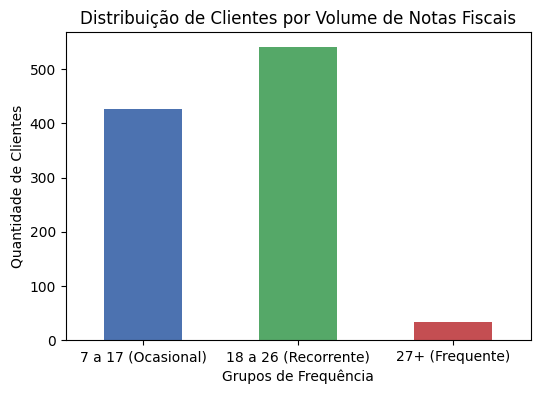

In [488]:
#############################################################    
# AED -> Frequência (3 Grandes Grupos)
# Objetivo: Criar 3 grupos de clientes classificando quantidade de notas 
#############################################################  

# 1. Contar o número de notas fiscais únicas por cliente
notas_por_cliente = df_limpo.groupby('Num_Cliente')['Nota_Fiscal'].nunique()
nf_por_cliente_estatistica = notas_por_cliente.describe() #-> Visualizar mínimo, 50% e máximo para criar faixas

# 2. Criar as faixas para os 3 grupos usando pd.cut
# float('inf') garante que o último intervalo seja aberto no limite superior
bins = [0, 17, 26, float('inf')]
labels = ['7 a 17 (Ocasional)', '18 a 26 (Recorrente)', '27+ (Frequente)']

# 3. Aplicar o cut e criar uma nova série com os grupos
grupos_frequencia = pd.cut(notas_por_cliente, bins=bins, labels=labels)

# 4. Ver a distribuição de clientes em cada grupo
resumo_grupos = grupos_frequencia.value_counts().sort_index()
print('Quantidade de Clientes por grupo de Frequência:')
print(resumo_grupos)

print('\nEstatística de Notas por cliente:')
print(nf_por_cliente_estatistica)

# 5. (Opcional) Visualizar em um gráfico de barras
plt.figure(figsize=(6, 4))
resumo_grupos.plot(kind='bar', color=['#4C72B0', '#55A868', '#C44E52'])
plt.title('Distribuição de Clientes por Volume de Notas Fiscais')
plt.xlabel('Grupos de Frequência')
plt.ylabel('Quantidade de Clientes')
plt.xticks(rotation=0)
plt.show()


Mostrando o volume de vendas por Classe Econômica
                  Quantidade_Itens_Vendidos  Representatividade (%)
Classe_Economica                                                   
B                                    530163                   63.88
C                                    232101                   27.96
A                                     67736                    8.16


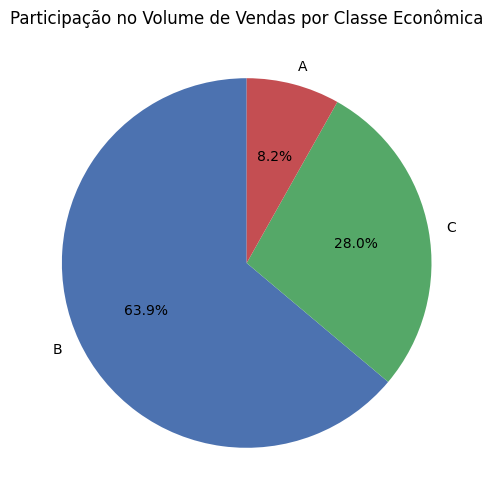

In [489]:
#############################################################    
# AED -> Volume de Vendas por Classe Econômica  
# Objetivo: Mostrar qual classe é o perfil principal do negócio
#############################################################  

# 1. Calcular o volume total de itens vendidos por classe
volume_por_classe = df_limpo['Classe_Economica'].value_counts()

# 2. Calcular o percentual de representatividade de cada classe
# O parâmetro "normalize=True" faz com que, em vez de retornar o número absoluto de ocorrências, 
# a função retorne a proporção (valor entre 0 e 1) de cada categoria em relação ao total.
percentual_por_classe = df_limpo['Classe_Economica'].value_counts(normalize=True) * 100

# 3. Juntar tudo em um DataFrame para facilitar a leitura
resumo_volume_classe = pd.DataFrame({
    'Quantidade_Itens_Vendidos': volume_por_classe,
    'Representatividade (%)': percentual_por_classe.round(2)
})

print('Mostrando o volume de vendas por Classe Econômica')
print(resumo_volume_classe)

# 4. Visualizar em um gráfico de pizza (para ver a fatia de mercado de cada classe)
plt.figure(figsize=(6, 6))
plt.pie(
    volume_por_classe, 
    labels=volume_por_classe.index, 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=['#4C72B0', '#55A868', '#C44E52']
)
plt.title('Participação no Volume de Vendas por Classe Econômica')
plt.show()

In [490]:
#############################################################    
# AED -> Sazonalidades (Dia da Semana / Mensal / Períodos do Mês)
# Objetivo: Nas próximas 3 células analizaremos picos de vendas por perídos específicos.
#############################################################  


Vendas (em quantidade de produtos) por dia da semana:
Dia_Semana
Segunda    111786
Terça      101656
Quarta     153560
Quinta     105474
Sexta      132633
Sábado      94388
Domingo    130503
dtype: int64


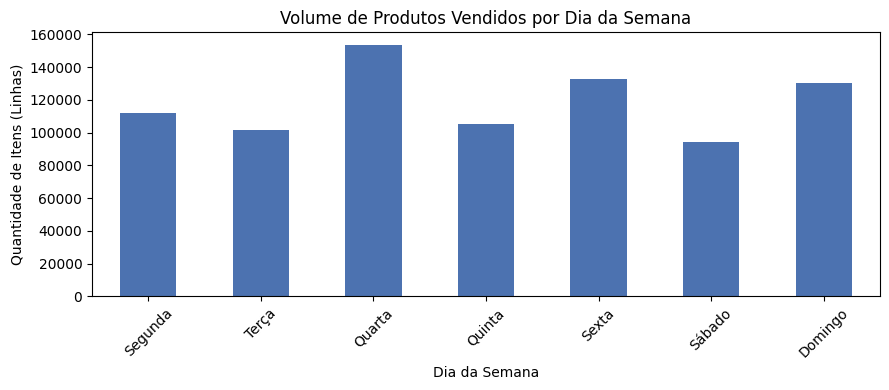

In [491]:
#############################################################    
# ANÁLISE 1 -> Sazonalidade por Dia da Semana
#############################################################  

# Dicionário de tradução
dicionario_dias = {
    0: 'Segunda',
    1: 'Terça',
    2: 'Quarta',
    3: 'Quinta',
    4: 'Sexta',
    5: 'Sábado',
    6: 'Domingo'
}

# Mapeando os numeros com replace para nomes
df_limpo['Dia_Semana'] = df_limpo['Dia_Semana'].replace(dicionario_dias)

# Transformar a coluna em categoria para manter a ordem correta no gráfico e não em ordem alfabética
ordem_correta = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']
df_limpo['Dia_Semana'] = pd.Categorical(df_limpo['Dia_Semana'], categories=ordem_correta, ordered=True)


# Contar a quantidade de itens por dia da semana (já com os nomes aplicados)
itens_dia_semana = df_limpo.groupby('Dia_Semana').size()
print('Vendas (em quantidade de produtos) por dia da semana:')
print(itens_dia_semana)

plt.figure(figsize=(9, 4))
itens_dia_semana.plot(kind='bar', color='#4C72B0')
plt.title('Volume de Produtos Vendidos por Dia da Semana')
plt.xlabel('Dia da Semana')
plt.ylabel('Quantidade de Itens (Linhas)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()




Quantidade de produtos vendidos por Mês:
Mes
1     83963
2     76201
3     64371
4     66935
5     82275
6     67808
7     68983
8     65609
9     68594
10    73900
11    40912
12    70449
dtype: int64


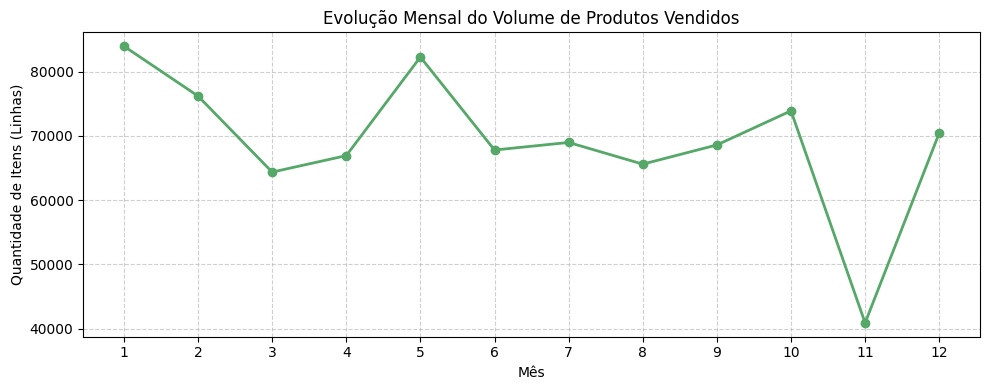

In [492]:
#############################################################    
# ANÁLISE 2 -> Sazonalidade Mensal
#############################################################

# Contamos a quantidade de itens por mês
itens_por_mes = df_limpo.groupby('Mes').size()
print('Quantidade de produtos vendidos por Mês:')
print(itens_por_mes)

plt.figure(figsize=(10, 4))
itens_por_mes.plot(kind='line', marker='o', color='#55A868', linewidth=2)
plt.xticks(itens_por_mes.index) 
plt.title('Evolução Mensal do Volume de Produtos Vendidos')
plt.xlabel('Mês')
plt.ylabel('Quantidade de Itens (Linhas)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()  

Mostrando a quantidade de produtos vendidos por períodos do Mês:
Periodo_Mes
Dias 01 a 10    305764
Dias 11 a 20    260549
Dias 21 a 31    263687
dtype: int64


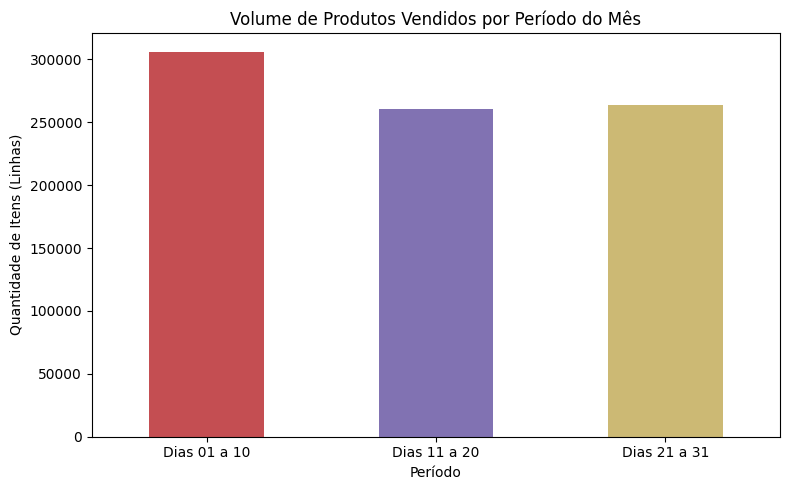

In [493]:
#############################################################    
# ANÁLISE 3 -> Distribuição de Vendas por Período do Mês
#############################################################  

# Definir as faixas de dias
bins_dias = [0, 10, 20, 31]
labels_periodos = ['Dias 01 a 10', 'Dias 11 a 20', 'Dias 21 a 31']

# Garantir que a coluna Periodo_Mes exista
if 'Periodo_Mes' not in df_limpo.columns:
    df_limpo['Periodo_Mes'] = pd.cut(df_limpo['Dia'], bins=bins_dias, labels=labels_periodos)

# Contamos a quantidade de itens por período
itens_por_periodo = df_limpo.groupby('Periodo_Mes').size()
print('Mostrando a quantidade de produtos vendidos por períodos do Mês:')
print(itens_por_periodo)

plt.figure(figsize=(8, 5))
itens_por_periodo.plot(kind='bar', color=['#C44E52', '#8172B2', '#CCB974'])
plt.title('Volume de Produtos Vendidos por Período do Mês')
plt.xlabel('Período')
plt.ylabel('Quantidade de Itens (Linhas)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Mostrando volume de vendas de produtos por categoria:
Cat_Produto
ALIMENTOS           434767
HIGIENE             155574
LIMPEZA             145754
BEBIDAS              43299
PET                  32399
ACESSORIOS           14557
Não Identificado      3650
Name: count, dtype: int64


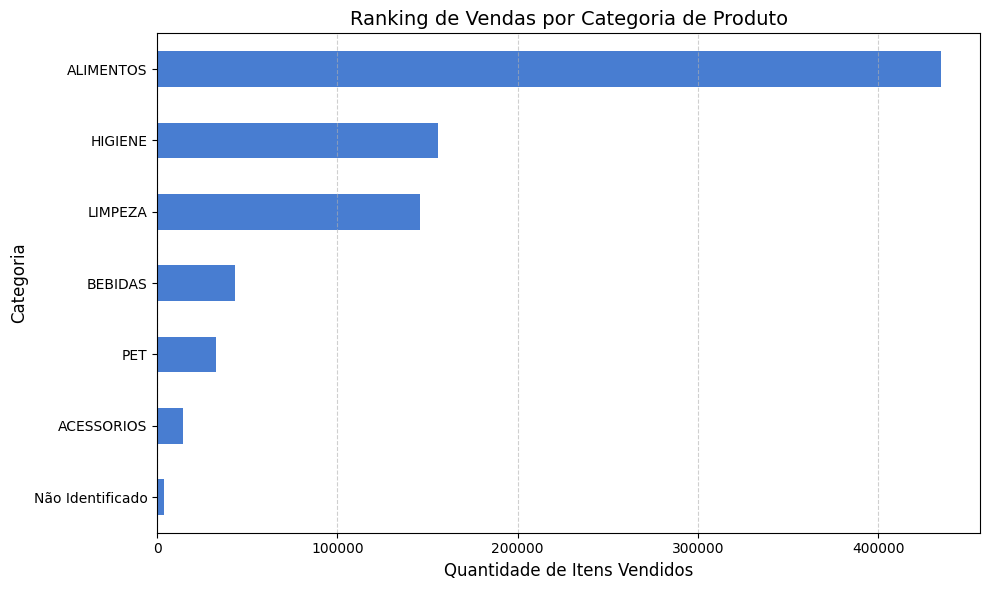

In [494]:
#############################################################    
# AED -> Volume de Vendas por Categoria de produtos 
# Objetivo: Entender quais setores representam o volume de vendas do negócio
#############################################################  

# Calcular o volume total de itens vendidos por categoria
vendas_por_categoria = df_limpo['Cat_Produto'].value_counts()

# Mostrar o resultado em texto já ordenado (.value_counts)
print("Mostrando volume de vendas de produtos por categoria:")
print(vendas_por_categoria)

# Gerar o gráfico de barras horizontais
plt.figure(figsize=(10, 6))
# Inverter a ordem para que a maior categoria fique no topo do gráfico
vendas_por_categoria.sort_values(ascending=True).plot(kind='barh', color="#487DD1")

plt.title('Ranking de Vendas por Categoria de Produto', fontsize=14)
plt.xlabel('Quantidade de Itens Vendidos', fontsize=12)
plt.ylabel('Categoria', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6) # Linhas de grade apenas verticais para ajudar a ler o volume
plt.tight_layout()
plt.show()

---

## Finalização do Projeto

Todo o pipeline de ETL e AED contou com verificações minusciosas para validar a integridade dos dados e integridade das regras de negócio. Após foram gerados alguns insights e gráficos com o cruzamento dos dados.

---

### Durante a transformação dos dados foram encontradas algumas inconsistências e foram necessários fazer ajustes a estrutura geral da base:

---

Existiam 4 colunas sem dado algum, provavelmente o arquivo csv continha mais separadores (;) ao final de cada linha, o que fez o interpretador carregar como colunas extras. Solução: Estas colunas foram removidas

---

Os nomes das colunas não eram legíveis, então todas as colunas foram renomeadas para fácil compreensão. Novos nomes: 'Data', 'Nota_Fiscal', 'Num_Cliente', 'Sexo', 'Estado_Civil', 'Num_Filhos', 'Classe_Economica', 'Cod_Produto', 'Cat_Produto', 'Nome_Produto'

---

Existiam 96.553 linhas "duplicadas". Antes de excluir qualquer linha, foi feita uma análise precisa para determinar se estas linhas eram erros, inconsistência, ou estrutura real da base de dados. 

Após profunda análise envolvendo a frequência que cada produto aparecia nas notas, verificação de dados estatísticos sobre as quantidades encontradas, análise detalhada de nota fiscal de exemplo e o impacto da remoção da duplicatas (que representa 11,6% da base), foi concluido que os registros repetidos são uma representação implícita de quantidade vendida de cada produto e não erro de duplicação. 

O que reforça esta tese é a ausência de uma coluna de quantidade, sendo assim, para cada produto vendido repetido é lançada uma nova linha na base. Desta forma os registros foram mantidos na base.

---

Foram corrigidos os tipos de dados. A coluna "Data" foi transformada em "datetime", as colunas categóricas transformadas em "category" e a coluna "Num_Filhos" transformada em "int8" resultando em uma otimização da base e economia de 94,19% de memória.

---

Foram verificadas inconsistência nos dados nas colunas "Sexo", "Estado_Civil", "Classe_Economica" e "Cat_Produto". Econtrada apenas nesta última coluna.

---

Na coluna "Cat_Produto" foi encontrada uma categoria "#N/D". Antes de tratar este dado foi feita uma investigação para encontrar quantos e quais produtos estavam ligados a essa categoria. 

Foi encontrado somente um produto de Cod_Produto=107. Após esta descoberta a investigação continuou para sabermos se o produto 107 aparecia em mais de uma categoria além da "#N/D" e se existia outro produto com o mesmo nome. 

Depois foi medido o impacto na inconsistência deste dado que afetavam 3650 linhas, 3228 notas distintas e 956 clientes distintos. 

Com a finalização da investigação conluiu-se que não existia informação alternativa para recuperar ou reclassificar o produto 107, então tanto a categoria como o produto nomeados com "#N/D" foram renomeados para "Não Identificado".

---

A análise de inconsistência seguiu na base de dados e foram verificados as seguintes questões: 

1. Existe o mesmo produto em multiplas categorias? 

2. Existe o mesmo Cod_Produto em multiplos produtos (Nome_Produto)? 

3. Existem produtos associados a mais de um Código? 

Somente nesse último item a resposta foi positiva, necessitando de aprofundamento na investigação.

---

Quanto a resposta anterior de que existiam produtos (Nome_Produto) com mais de um Cod_Produto, foram encontrados 108 produtos com 2 códigos e 1 produto com 4 códigos. 

Na investigação, descobriu-se que estes produtos representavam 92.4% de todos os produtos (quase toda a base). 

-> 92.4% dos produtos tem 2 códigos (quase toda a base)

-> Se fosse um erro cadastral ou problema de qualidade dos dados, esperaríamos valores menores como 5% / 10% / 15%. Se isso está ocorrendo em praticamente toda a base, não parece uma anomalia e sim uma característica do modelo de dados. 

-> A verificação anterior mostrou que o contrário não é verdadeiro, não existe Cod_Produto associado a mais de um produto, isso é mais importante para consistência cadastral. 

-> Os resultados sugerem que as ocorrências podem estar relacionadas a mudanças de codificação ou à existência de diferentes SKUs compartilhando uma mesma descrição comercial, e não necessariamente a erros cadastrais.

-> Isso sugere que a base de dados está estruturada da seguinte forma:
```
Nome_Produto (Arroz)
    ├── Cod_Produto 101 (Ex: Arroz Branco)
    └── Cod_Produto 102 (Ex: Arroz Integral)
```

-> Conclusão Final: Não é uma inconsistência.

---

Ainda na investigação de inconsistências foram cruzados os dados da Dimensão do Produto (combinação única de código, nome e categoria) vs Cod_Produto com as seguintes conclusões:

-> 229 combinações únicas de (Cod_Produto, Nome_Produto, Cat_Produto)

-> Cada Cod_Produto aparece associado a exatamente um único nome e uma única categoria

-> Em outras palavras: </br>
       * Não existem SKUs ambíguos. </br>
       * Um SKU nunca aponta para dois produtos diferentes. </br>
       * Um SKU nunca muda de categoria. </br>

-> Isso demonstra que "Cod_Produto" é provavelmente a "Primary Key" dessa base de dados (valores exclusivos (sem duplicatas) e não nulos (NOT NULL))

---

### Engenharia de Features e carga (Load) da base limpa:

---

Foram criadas 3 novas features temporais (colunas) extraindo-se o dia, o mês e o dia da semana da coluna "Data".

Colunas atualizadas da base:
['Data', 'Nota_Fiscal', 'Num_Cliente', 'Sexo', 'Estado_Civil', 'Num_Filhos', 'Classe_Economica', 'Cod_Produto', 'Cat_Produto', 'Nome_Produto', 'Dia', 'Mes', 'Dia_Semana']

---

A base da dados limpa e enriquecida das novas features foi salva do DataFrame "df_limpo" para o arquivo "Base_Varejo_limpo.csv"

---

### Engenharia de Features, carga (Load) da base limpa e Validação de regra de negócio:

---

Conforme solicitado no brief do mini projeto, foram extraidas as estatísticas da coluna "Num_Filhos", conclusão:

A mediana é o valor central, como nas estatísticas temos 50% exibido como "0" e também podemos ver na distribuição que mais de 50% dos valores está no "0", concluímos que a media é "0". Em relação as outras estatísticas, temos uma média de 1.14 filhos por cliente, desvio padrão de 1.41, moda igual a 0, variando entre o mínimo de 0 e máximo de 4, considerando 830 mil registros.

---

Outro critério do brief do mini projeto era validar a regra do identificaodr de número de compra (NF). Então foi verificado se existia alguma Nota_Fiscal atribuida a mais de um cliente e se existia alguma Nota_Fiscal com mais de uma data. Ambas as respostas foram negativas, validando a integridade dos registros.

---

### AED - Análise e insights:

---

Na primeira análise foi agrupado todas as notas fiscais únicas por cliente e depois separado em 3 grandes grupos. Observando a estatística desse agrupamento, verificou-se que o cliente com menor número de notas tinha 7 e com maior número de notas tinha 34, sendo a média 18.47. Então os grupos foram divididos entre 7 a 17 (Ocasional), 18 a 26 (Recorrente) e 27+ (Frequente).

Após foi criado o gráfico com as informações descobrindo que a grade maioria dos clientes se encontram na faixa "Recorrente".

---

Na segunda análise foram extraídas o volume de vendas (produtos) por classe econômica e exibido em um gráfico de pizza. Nesta informação podemos notar que a grande parte das vendas vem de clientes da classe B com 63.9%, ficando a classe C em segundo com 28% e a classe A com 8.2%.

---

Na terceira, quarta e quinta análises o foco foi nas sazonalidades (Utilizando as novas features criadas):

1. Por dia da semana -> Com picos de vendas na seguinte ordem: Quarta, Sexta, Domingo, Segunda, Quinta, Terça e Sábado

2. Por mês -> A análise foi plotada em um gráfico de linhas, podendo ver a variação ao longo do ano, sendo o maior volume de vendas no mês de Janeiro (1) e o menor no mês de Novembro (11)

3. Por perído do mês -> Através da coluna "Dia", extraida com dt.day da coluna "Data", foram criados 3 grupos das seguintes faixas "Dias 01 a 10", "Dias 11 a 20" e "Dias 21 a 31". Após contar a quantidade de itens vendidos por período, foi criado um gráfico de barras para interpretação e a maioria das vendas aconteceram na primeira faixa do início do mês.

---

Na sexta e última análise o objetivo era medir a volume de vendas por categoria de produtos. O resultado foi colocado em um gráfico de barras horizontais e ordenados da categoria com mais vendas para a que continha menos vendas. A ordem ficou: Alimentos, Higiene, Limpeza, Bebidas, Pet, Acessorios e Não Identificado.

---



